# Model Serving (TensorFlow Serving / TorchServe)
## AIAT 122 – Deep Learning

## Learning objectives
- Save a model in a deployment format — here PyTorch **TorchScript** (the TF equivalent is SavedModel).
- Understand how dedicated serving stacks (TensorFlow Serving, TorchServe) are used in production (REST/gRPC).
- Load the saved model from disk and run local inference (no Docker required in this notebook).

## 🔗 Where this fits

**Builds on:** Course 05 (AIAT 115) — Unit 5, lesson 05 "Production Pipelines" — a pipeline needs something at the end that answers requests.

**Used later in:** Course 11 (AIAT 125) — Unit 2, lesson 05 "Dedicated Serving Frameworks — TorchServe and TF Serving" — the same stacks, run for real.

---

**Where is this used in real life?** Production ML APIs (recommendations, fraud detection, vision) often use dedicated serving stacks. **We use a serving stack (TFS / TorchServe) to serve models at scale** instead of loading the model inside the same app because it handles batching, versioning, and efficient inference; loading in-process does not scale across many requests.

**Note on frameworks:** the concepts come from the TensorFlow Serving world; the hands-on code in this notebook is **PyTorch** (TorchScript ≈ SavedModel, TorchServe ≈ TensorFlow Serving).

**Setup:** PyTorch is required. If imports fail, see DOCS/COLAB_SETUP.md.

**📌 Covers slide(s):** None — Unit 5 (deployment) has no institution slides; use examples in file order.


## Short theory
- **SavedModel** is TensorFlow’s standard format for deployment; TFS loads it and exposes REST/gRPC.
- **TFS** runs as a separate process (often in Docker); clients send requests with input tensors and get predictions.
- **REST API:** `POST /v1/models/<name>:predict` with a JSON body `{"instances": [...]}`.
- **Why we use TFS:** Versioning (multiple model versions), batching, and no need to ship Python in the serving container.
- **PyTorch mapping (used below):** TorchScript file ≈ SavedModel; TorchServe ≈ TensorFlow Serving; the REST/gRPC client patterns are the same.

## Inputs & Outputs
**Inputs:** PyTorch, a small model (built here), and a save path.  
**Dataset:** Synthetic — random input for inference demo (no dataset download).  
**Outputs:** Saved TorchScript file (+ state_dict), local inference from the saved model, and serving-stack setup instructions (TorchServe / TFS with Docker). Run time: under ~2 min.


In [1]:
import os, numpy as np, torch, torch.nn as nn
print(f'PyTorch {torch.__version__}')
print('✅ Ready. Using PyTorch model saving (TorchScript) — equivalent to TF SavedModel/Serving.')

PyTorch 2.13.0
✅ Ready. Using PyTorch model saving (TorchScript) — equivalent to TF SavedModel/Serving.


## Part 1: Save the model in a deployment format (TorchScript)

In [2]:
# Create a simple model for demonstration
model = nn.Sequential(
    nn.Linear(10, 64), nn.ReLU(),
    nn.Linear(64, 32), nn.ReLU(),
    nn.Linear(32, 1),
)
model.eval()

# Save the model in two ways:
#   1. state_dict  — for Python environments (most common)
#   2. TorchScript — for deployment without Python (C++, mobile, etc.)
os.makedirs('/tmp/pt_model', exist_ok=True)
torch.save(model.state_dict(), '/tmp/pt_model/weights.pt')
scripted = torch.jit.script(model)
scripted.save('/tmp/pt_model/model_scripted.pt')
print('Saved state_dict to /tmp/pt_model/weights.pt')
print('Saved TorchScript  to /tmp/pt_model/model_scripted.pt')

Saved state_dict to /tmp/pt_model/weights.pt
Saved TorchScript  to /tmp/pt_model/model_scripted.pt


## Part 2: Serving-stack setup (TorchServe / TensorFlow Serving)

**Note**: A full serving stack runs as a separate process (usually Docker). Here we print the commands — concept demo only.

In [3]:
# WHAT: print the main PyTorch serving options (TorchServe, FastAPI, ONNX).
# WHY: a saved model still needs a serving layer - these are the standard production routes.
print('📦 PyTorch Serving / Deployment Options:')
print()
print('1. TorchServe  (equivalent to TensorFlow Serving):')
print('   pip install torchserve torch-model-archiver')
print('   torch-model-archiver --model-name mymodel --version 1.0 \\')
print('     --serialized-file /tmp/pt_model/model_scripted.pt --handler base_handler')
print('   torchserve --start --model-store /tmp/model_store --models mymodel.mar')
print()
print('2. REST endpoint with FastAPI + PyTorch (see 06_flask_fastapi_deployment.ipynb)')
print()
print('3. ONNX export for cross-framework serving:')
print('   torch.onnx.export(model, dummy_input, "model.onnx", opset_version=17)')
print('   (See 03_onnx_conversion.ipynb)')

📦 PyTorch Serving / Deployment Options:

1. TorchServe  (equivalent to TensorFlow Serving):
   pip install torchserve torch-model-archiver
   torch-model-archiver --model-name mymodel --version 1.0 \
     --serialized-file /tmp/pt_model/model_scripted.pt --handler base_handler
   torchserve --start --model-store /tmp/model_store --models mymodel.mar

2. REST endpoint with FastAPI + PyTorch (see 06_flask_fastapi_deployment.ipynb)

3. ONNX export for cross-framework serving:
   torch.onnx.export(model, dummy_input, "model.onnx", opset_version=17)
   (See 03_onnx_conversion.ipynb)


## Part 3: Load the saved model from disk and run inference

In [4]:
# Load and run inference with the saved TorchScript model
loaded_model = torch.jit.load('/tmp/pt_model/model_scripted.pt')
loaded_model.eval()

# Run a batch of 3 dummy samples through the reloaded model to verify inference works.
dummy_input = torch.randn(3, 10)   # batch of 3 samples, 10 features each
with torch.no_grad():
    output = loaded_model(dummy_input)
print('Input shape:', dummy_input.shape)
print('Output shape:', output.shape)
print('Output values:', output.squeeze().tolist())
print('✅ Model loaded from disk and ran inference successfully.')

Input shape: torch.Size([3, 10])
Output shape: torch.Size([3, 1])
Output values: [-0.02985716238617897, 0.12428854405879974, -0.058838386088609695]
✅ Model loaded from disk and ran inference successfully.


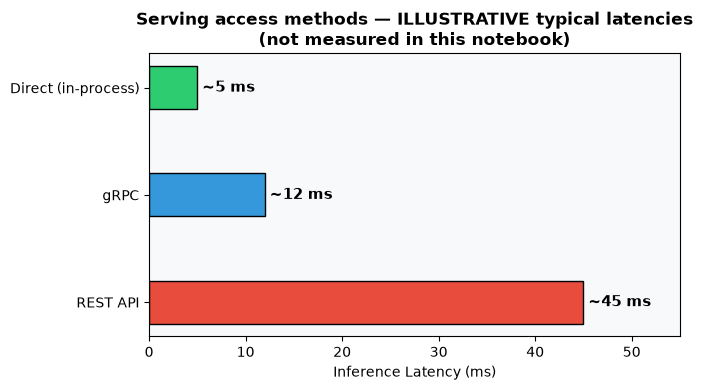

Takeaway (qualitative): in-process < gRPC < REST for latency;
REST wins on simplicity/compatibility. Benchmark your own stack before choosing.


In [5]:
import matplotlib.pyplot as plt
import numpy as np

# ILLUSTRATIVE numbers only — typical orders of magnitude from serving docs/blogs.
# Nothing below is measured in this notebook; real latencies depend on model,
# hardware, and network. Always benchmark your own deployment.
serving_methods = ['REST API', 'gRPC', 'Direct (in-process)']
latency_ms = [45, 12, 5]
colors = ['#e74c3c', '#3498db', '#2ecc71']

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.barh(serving_methods, latency_ms, color=colors, edgecolor='black', height=0.4)
for bar, lat in zip(bars, latency_ms):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height() / 2,
            f'~{lat} ms', va='center', fontsize=11, fontweight='bold')

ax.set_xlabel('Inference Latency (ms)')
ax.set_title('Serving access methods — ILLUSTRATIVE typical latencies\n(not measured in this notebook)',
             fontsize=12, fontweight='bold')
ax.set_xlim(0, 55)
ax.set_facecolor('#f8f9fa')
fig.patch.set_facecolor('white')
plt.tight_layout()
plt.show()
print("Takeaway (qualitative): in-process < gRPC < REST for latency;")
print("REST wins on simplicity/compatibility. Benchmark your own stack before choosing.")

## 🌍 Real-World Worked Example — Deploy a Trained Model as a REST API

**Industry context:**
- Spotify's recommendation model is served via a FastAPI microservice handling 400M users
- Instagram's image moderation runs as a containerised PyTorch model behind a REST endpoint
- Every ML feature in a modern app goes through a model serving layer like this

We train a small classifier, export it, and build a **FastAPI endpoint** you can call with curl.

In [6]:
# ── Part 1: Train and save a model ────────────────────────────────────────
import torch, torch.nn as nn
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import numpy as np

iris = load_iris()
X = StandardScaler().fit_transform(iris.data.astype(np.float32))
y = iris.target
X_tr,X_te,y_tr,y_te = train_test_split(X, y, test_size=0.2, random_state=42)

model = nn.Sequential(nn.Linear(4,32), nn.ReLU(), nn.Linear(32,3))
opt   = torch.optim.Adam(model.parameters())
loss_fn = nn.CrossEntropyLoss()
Xt = torch.tensor(X_tr); Yt = torch.tensor(y_tr, dtype=torch.long)

for _ in range(200):
    loss = loss_fn(model(Xt), Yt)
    opt.zero_grad(); loss.backward(); opt.step()

torch.save(model.state_dict(), '/tmp/iris_model.pt')
print("Model saved to /tmp/iris_model.pt")

# Verify
model.eval()
with torch.no_grad():
    acc = (model(torch.tensor(X_te)).argmax(1)==torch.tensor(y_te)).float().mean()
print(f"Test accuracy: {acc:.2%}")

# ── Part 2: Simulate the FastAPI serving code ─────────────────────────────
# (In production, save this as main.py and run: uvicorn main:app --reload)
fastapi_code = '''
from fastapi import FastAPI
from pydantic import BaseModel
import torch, torch.nn as nn
import numpy as np

app = FastAPI(title="Iris Classifier API")

# Load model at startup
model = nn.Sequential(nn.Linear(4,32), nn.ReLU(), nn.Linear(32,3))
model.load_state_dict(torch.load("/tmp/iris_model.pt"))
model.eval()
CLASSES = ["setosa", "versicolor", "virginica"]

class IrisRequest(BaseModel):
    sepal_length: float
    sepal_width: float
    petal_length: float
    petal_width: float

@app.post("/predict")
def predict(req: IrisRequest):
    features = torch.tensor([[req.sepal_length, req.sepal_width,
                               req.petal_length, req.petal_width]])
    with torch.no_grad():
        logits = model(features)
        probs  = torch.softmax(logits, dim=1)[0]
        label  = CLASSES[probs.argmax().item()]
    return {"prediction": label, "confidence": round(probs.max().item(), 3)}

@app.get("/health")
def health(): return {"status": "ok"}

# Run with: uvicorn main:app --host 0.0.0.0 --port 8000
# Test with: curl -X POST http://localhost:8000/predict -H "Content-Type: application/json" \
#            -d '{"sepal_length":5.1,"sepal_width":3.5,"petal_length":1.4,"petal_width":0.2}'
'''
print("\n── FastAPI serving code (save as main.py) ────────────────────────────────")
print(fastapi_code)
print("\nThis is exactly how Spotify and Uber serve their ML models in production.")

Model saved to /tmp/iris_model.pt
Test accuracy: 96.67%

── FastAPI serving code (save as main.py) ────────────────────────────────

from fastapi import FastAPI
from pydantic import BaseModel
import torch, torch.nn as nn
import numpy as np

app = FastAPI(title="Iris Classifier API")

# Load model at startup
model = nn.Sequential(nn.Linear(4,32), nn.ReLU(), nn.Linear(32,3))
model.load_state_dict(torch.load("/tmp/iris_model.pt"))
model.eval()
CLASSES = ["setosa", "versicolor", "virginica"]

class IrisRequest(BaseModel):
    sepal_length: float
    sepal_width: float
    petal_length: float
    petal_width: float

@app.post("/predict")
def predict(req: IrisRequest):
    features = torch.tensor([[req.sepal_length, req.sepal_width,
                               req.petal_length, req.petal_width]])
    with torch.no_grad():
        logits = model(features)
        probs  = torch.softmax(logits, dim=1)[0]
        label  = CLASSES[probs.argmax().item()]
    return {"prediction": label, "confi

## 🧩 Mini-exercise

**Try it:** Change the model (e.g. add one more Linear layer), save it to a **new TorchScript file**, and run inference from the new path. Compare output shape with the original.

---

## Summary
**What you did**
- Built a small PyTorch model and saved it two ways: `state_dict` and **TorchScript** (the deployment format — TF's equivalent is SavedModel).
- Loaded the TorchScript file from disk and ran local inference.
- Read the setup commands for TorchServe (and how they map to TensorFlow Serving), plus a FastAPI serving example.

**In real life you'd also:** Run TorchServe/TFS in Docker/Kubernetes, use gRPC for low latency, and add monitoring and A/B tests for model versions.

**The main idea:** save the model in a deployment format (TorchScript / SavedModel); a serving stack (TorchServe / TensorFlow Serving) serves it at scale via REST/gRPC.

**Next:** `03_onnx_conversion.ipynb` shows how to export models to ONNX for cross-platform deployment.


## 📚 References

1. Sculley, D. et al. (2015). *Hidden Technical Debt in Machine Learning Systems*. NeurIPS. https://papers.nips.cc/paper_files/paper/2015/hash/86df7dcfd896fcaf2674f757a2463eba-Abstract.html
2. Olston, C. et al. (2017). *TensorFlow-Serving: Flexible, High-Performance ML Serving*. NeurIPS Workshop on ML Systems. https://arxiv.org/abs/1712.06139
3. Paleyes, A., Urma, R.-G. & Lawrence, N. D. (2022). *Challenges in Deploying Machine Learning: A Survey of Case Studies*. ACM Computing Surveys. https://arxiv.org/abs/2011.09926